# Bank note Authentication - Model training

In [19]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("data/data_banknote_authentication.txt",header=None)
df.head()

,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [22]:
df.head()

,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [23]:
df.columns = ['variance','skewness','curtosis','entropy','class']

In [24]:
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [25]:
df.tail()

,variance,skewness,curtosis,entropy,class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


In [26]:
print("Shape: ",df.shape)

Shape:  (1372, 5)


In [27]:
print("Missing Values:",df.isnull().sum())

Missing Values: variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [28]:
df['class'].value_counts()

class
0    762
1    610
Name: count, dtype: int64

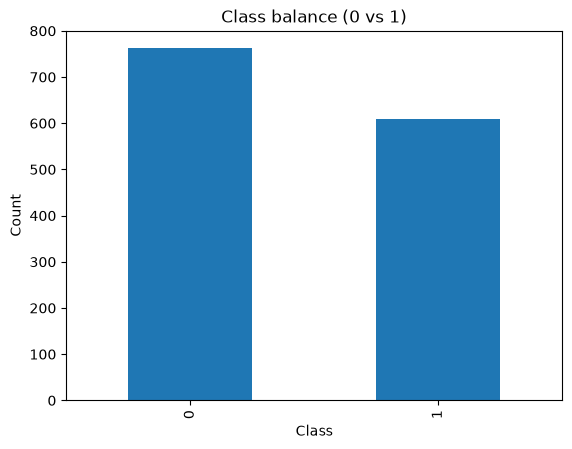

In [30]:
df['class'].value_counts().sort_index().plot(kind='bar')
plt.title("Class balance (0 vs 1)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [31]:
X = df.drop('class',axis=1)
y = df['class']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [34]:
y_pred = model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))
print("Confusion matrix: ", confusion_matrix(y_test,y_pred))

Accuracy:  0.9963636363636363
Classification Report:                precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

Confusion matrix:  [[152   1]
 [  0 122]]


In [35]:
model.feature_importances_

array([0.55739374, 0.23567262, 0.14770967, 0.05922398])

In [37]:
importance = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)
print(importance.round(4))


variance    0.5574
skewness    0.2357
curtosis    0.1477
entropy     0.0592
dtype: float64


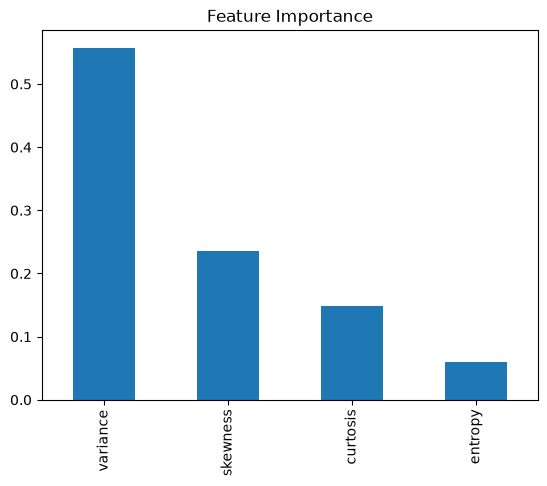

In [38]:
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

## Save the model

In [39]:
os.makedirs("model",exist_ok=True)
joblib.dump(model,"model/classifier.joblib")
print("Saved -> model/Classifier.joblib")

Saved -> model/Classifier.joblib


# Verify the model

In [46]:
import warnings
warnings.filterwarnings("ignore")

In [47]:
loaded_model = joblib.load("model/classifier.joblib")

sample = np.array([[3.6216,8.6661,-2.8073,-0.44699]])

pred = int(loaded_model.predict(sample)[0])

proba = float(loaded_model.predict_proba(sample)[0][pred])
label = "Forged note" if pred == 1 else "Authentic note"

print(f"Prediction:{pred} ({label}) | confidence: {proba:.4f}")

Prediction:0 (Authentic note) | confidence: 1.0000
